In [2]:
%load_ext autoreload
%autoreload 2


In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
assert (PROJECT_ROOT / "src").exists(), "src NOT FOUND — WRONG ROOT"

sys.path.insert(0, str(PROJECT_ROOT))

print(" Project root added:", PROJECT_ROOT)


import pandas as pd

from src.models import *


 Project root added: d:\projects\CreditPathAI_Oct_Batch


In [4]:

from src.utils import *
print_tree(PROJECT_ROOT  , depth=1)


CreditPathAI_Oct_Batch/
    .git/
        COMMIT_EDITMSG
        config
        description
        FETCH_HEAD
        HEAD
        index
        ORIG_HEAD
        packed-refs
    .gitattributes
    .gitignore
    .venv/
        .gitignore
        pyvenv.cfg
    artifacts/
    CreditPathAI_Oct_Batch/
    git
    kaggle_dataset/
        .gitignore
        README.md
        requirements.txt
    LICENSE
    main.py
    microsoft_dataset/
        microsoft_main.ipynb
    README.md
    requirements.txt
    src/
        eda.py
        evaluate.py
        inference.py
        ingestion.py
        models.py
        preprocess.py
        utils.py
        __init__.py
    streamlit/
        streamlit_app.py


In [5]:


import pandas as pd

preprocessed_path = PROJECT_ROOT /"microsoft_dataset/data/processed/merged_loan_preprocessed.csv"
df = pd.read_csv(preprocessed_path)


X = df.drop(columns=["defaultFlag"])
y = df["defaultFlag"]

In [6]:
print(preprocessed_path)

D:\projects\CreditPathAI_Oct_Batch\microsoft_dataset\data\processed\merged_loan_preprocessed.csv


In [7]:
df.head(10)

,memberId,residentialState,yearsEmployment,homeOwnership,annualIncome,incomeVerified,dtiRatio,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,...,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus,defaultFlag,date_year,date_month
0,2305095,30,1,2,56471,1,16.80,6,11,9.0,...,0.0,25190.0,2,6.25,490,14,Current,0,2014,12
1,2610493,45,2,2,55038,0,19.99,22,8,7.0,...,0.0,21189.0,2,10.49,455,5,Current,0,2014,9
2,2491679,23,4,2,56610,1,14.33,5,8,5.0,...,0.0,29908.0,2,9.11,622,4,Current,0,2014,9
3,2092798,41,3,1,54887,1,14.80,12,14,7.0,...,0.0,13053.0,1,11.89,343,5,Current,0,2016,4
4,2633077,17,2,2,53522,1,10.14,4,21,19.0,...,0.0,24613.0,2,15.13,587,2,Current,0,2016,2
5,2385245,28,2,2,58459,0,15.77,1,18,15.0,...,0.0,17905.0,2,10.43,384,0,Current,0,2015,11
6,2796457,44,3,2,56611,0,13.52,1,9,7.0,...,0.0,26238.0,0,10.96,859,5,Current,0,2014,5
7,2822245,3,1,0,58163,0,25.22,6,14,9.0,...,0.0,21940.0,1,10.28,559,3,Current,0,2015,4
8,2462353,13,1,2,55636,1,9.97,10,19,12.0,...,0.0,18195.0,0,12.08,605,0,Current,0,2014,10
9,2404666,12,3,0,54599,0,20.90,26,16,11.0,...,0.0,24418.0,1,11.63,639,3,Current,0,2015,12


In [8]:
df=df.drop(columns=['loanStatus'])
df.head(10)


,memberId,residentialState,yearsEmployment,homeOwnership,annualIncome,incomeVerified,dtiRatio,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,...,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,defaultFlag,date_year,date_month
0,2305095,30,1,2,56471,1,16.80,6,11,9.0,...,2,0.0,25190.0,2,6.25,490,14,0,2014,12
1,2610493,45,2,2,55038,0,19.99,22,8,7.0,...,2,0.0,21189.0,2,10.49,455,5,0,2014,9
2,2491679,23,4,2,56610,1,14.33,5,8,5.0,...,2,0.0,29908.0,2,9.11,622,4,0,2014,9
3,2092798,41,3,1,54887,1,14.80,12,14,7.0,...,5,0.0,13053.0,1,11.89,343,5,0,2016,4
4,2633077,17,2,2,53522,1,10.14,4,21,19.0,...,2,0.0,24613.0,2,15.13,587,2,0,2016,2
5,2385245,28,2,2,58459,0,15.77,1,18,15.0,...,2,0.0,17905.0,2,10.43,384,0,0,2015,11
6,2796457,44,3,2,56611,0,13.52,1,9,7.0,...,2,0.0,26238.0,0,10.96,859,5,0,2014,5
7,2822245,3,1,0,58163,0,25.22,6,14,9.0,...,4,0.0,21940.0,1,10.28,559,3,0,2015,4
8,2462353,13,1,2,55636,1,9.97,10,19,12.0,...,2,0.0,18195.0,0,12.08,605,0,0,2014,10
9,2404666,12,3,0,54599,0,20.90,26,16,11.0,...,2,0.0,24418.0,1,11.63,639,3,0,2015,12


In [9]:
X = df.drop(columns=['defaultFlag'])
y = df['defaultFlag']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [11]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Target distribution in train:")
print(y_train.value_counts())
print("Target distribution in test:")
print(y_test.value_counts())

Train shape: (80000, 27)
Test shape: (20000, 27)
Target distribution in train:
defaultFlag
0    71997
1     8003
Name: count, dtype: int64
Target distribution in test:
defaultFlag
0    17999
1     2001
Name: count, dtype: int64


In [12]:
from sklearn.preprocessing import StandardScaler

numeric_cols = X_train.select_dtypes(include="number").columns.tolist()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
from src.evaluate import evaluate_model
from src.models import train_model

In [14]:
df.head(10)

,memberId,residentialState,yearsEmployment,homeOwnership,annualIncome,incomeVerified,dtiRatio,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,...,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,defaultFlag,date_year,date_month
0,2305095,30,1,2,56471,1,16.80,6,11,9.0,...,2,0.0,25190.0,2,6.25,490,14,0,2014,12
1,2610493,45,2,2,55038,0,19.99,22,8,7.0,...,2,0.0,21189.0,2,10.49,455,5,0,2014,9
2,2491679,23,4,2,56610,1,14.33,5,8,5.0,...,2,0.0,29908.0,2,9.11,622,4,0,2014,9
3,2092798,41,3,1,54887,1,14.80,12,14,7.0,...,5,0.0,13053.0,1,11.89,343,5,0,2016,4
4,2633077,17,2,2,53522,1,10.14,4,21,19.0,...,2,0.0,24613.0,2,15.13,587,2,0,2016,2
5,2385245,28,2,2,58459,0,15.77,1,18,15.0,...,2,0.0,17905.0,2,10.43,384,0,0,2015,11
6,2796457,44,3,2,56611,0,13.52,1,9,7.0,...,2,0.0,26238.0,0,10.96,859,5,0,2014,5
7,2822245,3,1,0,58163,0,25.22,6,14,9.0,...,4,0.0,21940.0,1,10.28,559,3,0,2015,4
8,2462353,13,1,2,55636,1,9.97,10,19,12.0,...,2,0.0,18195.0,0,12.08,605,0,0,2014,10
9,2404666,12,3,0,54599,0,20.90,26,16,11.0,...,2,0.0,24418.0,1,11.63,639,3,0,2015,12


In [15]:


model = train_model(
    X_train,
    y_train,
    model_name="random_forest",
    use_smote=True
)

results = evaluate_model(model, X_test, y_test)
print(results["metrics"])
print(results["classification_report"])


import joblib

artifacts = {
    "scaler": scaler,
    "numeric_cols": numeric_cols,
    "feature_order": X_train.columns.tolist()
}


model_name = "random_forest"

ARTIFACTS_PATH = PROJECT_ROOT / "microsoft_dataset/articats"
model_path = ARTIFACTS_PATH / f"models/{model_name}.pkl"

model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(model, model_path)

print(f"Model saved to {model_path}")




{'accuracy': 0.897, 'precision': 0.4882047181127549, 'recall': 0.6101949025487257, 'f1_score': 0.5424255886272767, 'roc_auc': 0.8935888325629952}
              precision    recall  f1-score   support

           0       0.96      0.93      0.94     17999
           1       0.49      0.61      0.54      2001

    accuracy                           0.90     20000
   macro avg       0.72      0.77      0.74     20000
weighted avg       0.91      0.90      0.90     20000

Model saved to D:\projects\CreditPathAI_Oct_Batch\microsoft_dataset\articats\models\random_forest.pkl


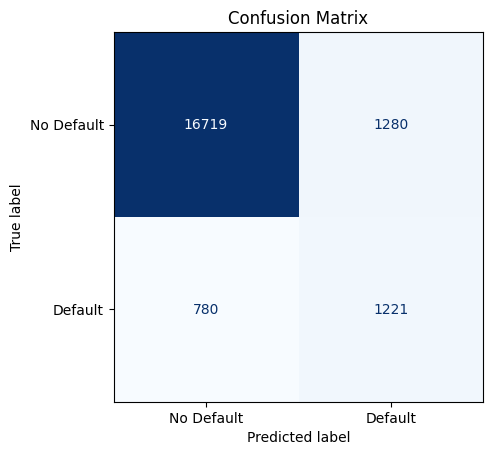

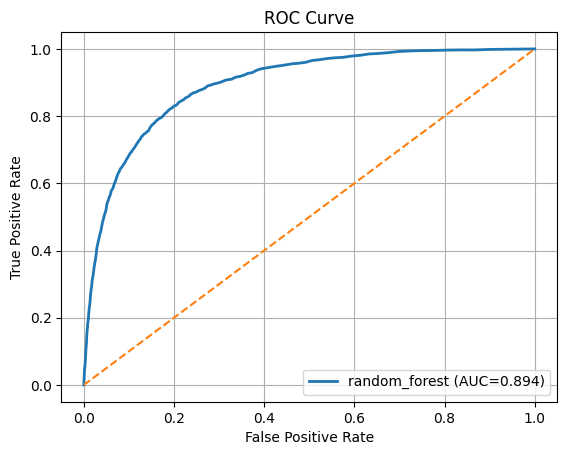

In [16]:
from src.evaluate import (
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall,
    plot_feature_importance
)

from src.evaluate import evaluate_model

results = evaluate_model(model, X_test, y_test)


plot_confusion_matrix(
    results["confusion_matrix"],
    class_names=["No Default", "Default"]
)

roc = results["roc_curve"]
plot_roc_curve(roc["fpr"], roc["tpr"], label=f'{model_name}')




In [17]:
model_name = "logistic_regression"

model = train_model(
    X_train,
    y_train,
    model_name=model_name,
    use_smote=True
)


results = evaluate_model(model, X_test, y_test)
print(results["metrics"])
print(results["classification_report"])


import joblib

artifacts = {
    "scaler": scaler,
    "numeric_cols": numeric_cols,
    "feature_order": X_train.columns.tolist()
}




model_path = ARTIFACTS_PATH / f"models/{model_name}.pkl"

model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(model, model_path)

print(f"Model saved to {model_path}")




d:\projects\CreditPathAI_Oct_Batch\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'accuracy': 0.8345, 'precision': 0.35567805953693493, 'recall': 0.8060969515242379, 'f1_score': 0.49357405140758875, 'roc_auc': 0.9032534402280498}
              precision    recall  f1-score   support

           0       0.97      0.84      0.90     17999
           1       0.36      0.81      0.49      2001

    accuracy                           0.83     20000
   macro avg       0.67      0.82      0.70     20000
weighted avg       0.91      0.83      0.86     20000

Model saved to D:\projects\CreditPathAI_Oct_Batch\microsoft_dataset\articats\models\logistic_regression.pkl


d:\projects\CreditPathAI_Oct_Batch\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


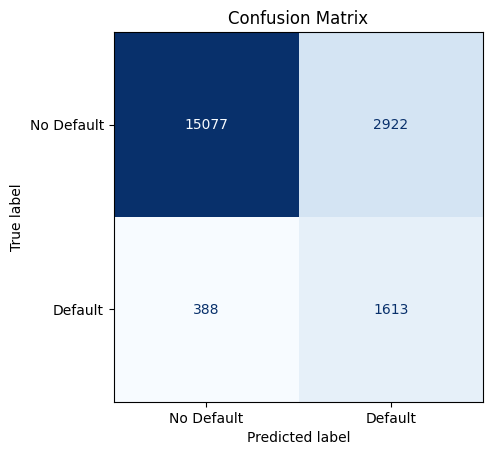

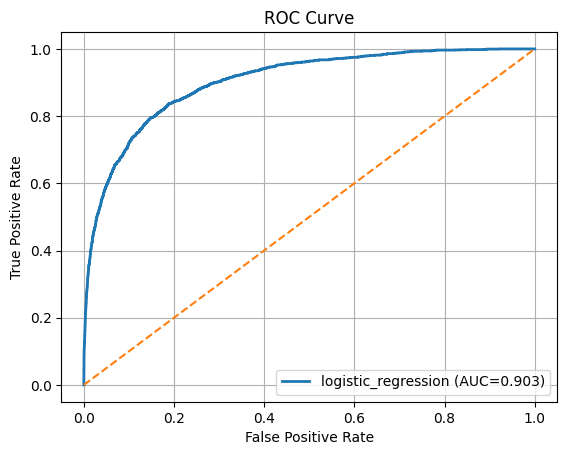

In [18]:
from src.evaluate import (
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall,
    plot_feature_importance
)

from src.evaluate import evaluate_model

results = evaluate_model(model, X_test, y_test)


plot_confusion_matrix(
    results["confusion_matrix"],
    class_names=["No Default", "Default"]
)

roc = results["roc_curve"]
plot_roc_curve(roc["fpr"], roc["tpr"], label=f'{model_name}')




In [19]:
model_name = "naive_bayes"

model = train_model(
    X_train,
    y_train,
    model_name=model_name,
    use_smote=True
)


results = evaluate_model(model, X_test, y_test)
print(results["metrics"])
print(results["classification_report"])


import joblib

artifacts = {
    "scaler": scaler,
    "numeric_cols": numeric_cols,
    "feature_order": X_train.columns.tolist()
}



model_path = ARTIFACTS_PATH / f"models/{model_name}.pkl"

model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(model, model_path)

print(f"Model saved to {model_path}")




{'accuracy': 0.73425, 'precision': 0.24333952912019827, 'recall': 0.7851074462768616, 'f1_score': 0.37152654605652125, 'roc_auc': 0.8420681042333437}
              precision    recall  f1-score   support

           0       0.97      0.73      0.83     17999
           1       0.24      0.79      0.37      2001

    accuracy                           0.73     20000
   macro avg       0.61      0.76      0.60     20000
weighted avg       0.90      0.73      0.79     20000

Model saved to D:\projects\CreditPathAI_Oct_Batch\microsoft_dataset\articats\models\naive_bayes.pkl


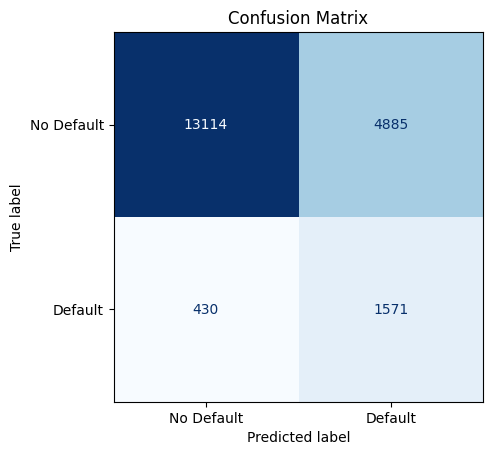

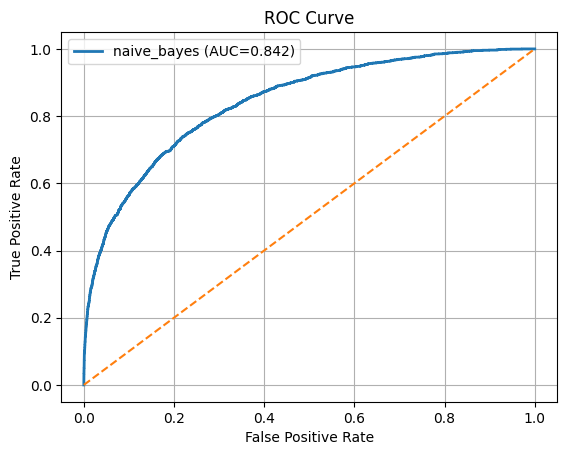

In [20]:
from src.evaluate import (
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall,
    plot_feature_importance
)

from src.evaluate import evaluate_model

results = evaluate_model(model, X_test, y_test)


plot_confusion_matrix(
    results["confusion_matrix"],
    class_names=["No Default", "Default"]
)

roc = results["roc_curve"]
plot_roc_curve(roc["fpr"], roc["tpr"], label=f'{model_name}')




In [21]:
model_name = "decision_tree"

model = train_model(
    X_train,
    y_train,
    model_name=model_name,
    use_smote=True
)


results = evaluate_model(model, X_test, y_test)
print(results["metrics"])
print(results["classification_report"])


import joblib

artifacts = {
    "scaler": scaler,
    "numeric_cols": numeric_cols,
    "feature_order": X_train.columns.tolist()
}




model_path = ARTIFACTS_PATH / f"models/{model_name}.pkl"

model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(model, model_path)

print(f"Model saved to {model_path}")




{'accuracy': 0.8217, 'precision': 0.29670044167316184, 'recall': 0.5707146426786607, 'f1_score': 0.39042735042735044, 'roc_auc': 0.7101586991936557}
              precision    recall  f1-score   support

           0       0.95      0.85      0.90     17999
           1       0.30      0.57      0.39      2001

    accuracy                           0.82     20000
   macro avg       0.62      0.71      0.64     20000
weighted avg       0.88      0.82      0.85     20000

Model saved to D:\projects\CreditPathAI_Oct_Batch\microsoft_dataset\articats\models\decision_tree.pkl


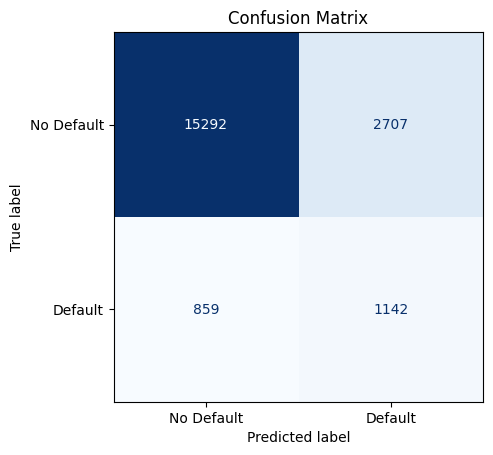

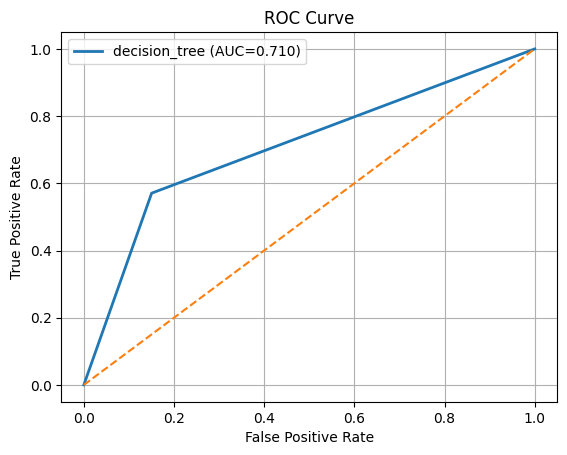

In [22]:
from src.evaluate import (
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall,
    plot_feature_importance
)

from src.evaluate import evaluate_model

results = evaluate_model(model, X_test, y_test)


plot_confusion_matrix(
    results["confusion_matrix"],
    class_names=["No Default", "Default"]
)

roc = results["roc_curve"]
plot_roc_curve(roc["fpr"], roc["tpr"], label=f'{model_name}')




In [23]:
model_name = "gradient_boosting"

model = train_model(
    X_train,
    y_train,
    model_name=model_name,
    use_smote=True
)


results = evaluate_model(model, X_test, y_test)
print(results["metrics"])
print(results["classification_report"])


import joblib

artifacts = {
    "scaler": scaler,
    "numeric_cols": numeric_cols,
    "feature_order": X_train.columns.tolist()
}




model_path = ARTIFACTS_PATH / f"models/{model_name}.pkl"

model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(model, model_path)

print(f"Model saved to {model_path}")




{'accuracy': 0.8769, 'precision': 0.42839391115253184, 'recall': 0.6891554222888556, 'f1_score': 0.5283524904214559, 'roc_auc': 0.896038146824693}
              precision    recall  f1-score   support

           0       0.96      0.90      0.93     17999
           1       0.43      0.69      0.53      2001

    accuracy                           0.88     20000
   macro avg       0.70      0.79      0.73     20000
weighted avg       0.91      0.88      0.89     20000

Model saved to D:\projects\CreditPathAI_Oct_Batch\microsoft_dataset\articats\models\gradient_boosting.pkl


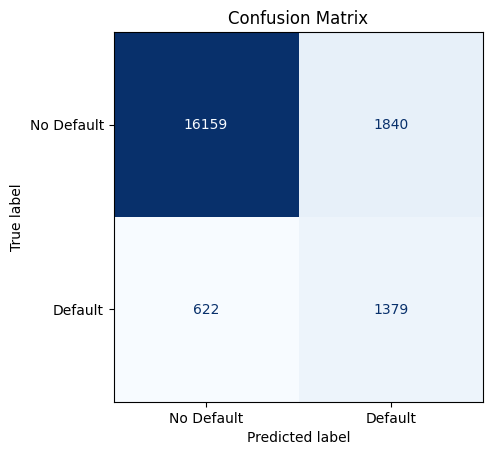

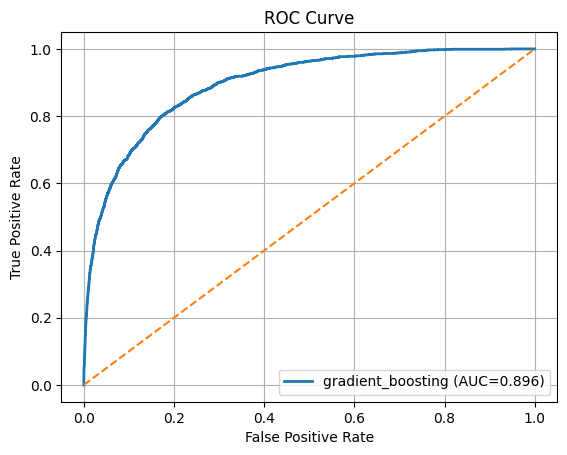

In [24]:
from src.evaluate import (
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall,
    plot_feature_importance
)

from src.evaluate import evaluate_model

results = evaluate_model(model, X_test, y_test)


plot_confusion_matrix(
    results["confusion_matrix"],
    class_names=["No Default", "Default"]
)

roc = results["roc_curve"]
plot_roc_curve(roc["fpr"], roc["tpr"], label=f'{model_name}')




In [25]:
model_name = "knn"

model = train_model(
    X_train,
    y_train,
    model_name=model_name,
    use_smote=True
)


results = evaluate_model(model, X_test, y_test)
print(results["metrics"])
print(results["classification_report"])


import joblib

artifacts = {
    "scaler": scaler,
    "numeric_cols": numeric_cols,
    "feature_order": X_train.columns.tolist()
}




model_path = ARTIFACTS_PATH / f"models/{model_name}.pkl"

model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(model, model_path)

print(f"Model saved to {model_path}")




{'accuracy': 0.70585, 'precision': 0.1535166012138522, 'recall': 0.42978510744627685, 'f1_score': 0.22622648954360122, 'roc_auc': 0.611090573941875}
              precision    recall  f1-score   support

           0       0.92      0.74      0.82     17999
           1       0.15      0.43      0.23      2001

    accuracy                           0.71     20000
   macro avg       0.54      0.58      0.52     20000
weighted avg       0.84      0.71      0.76     20000

Model saved to D:\projects\CreditPathAI_Oct_Batch\microsoft_dataset\articats\models\knn.pkl


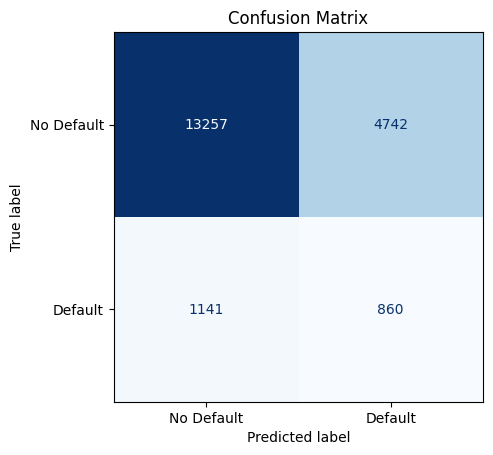

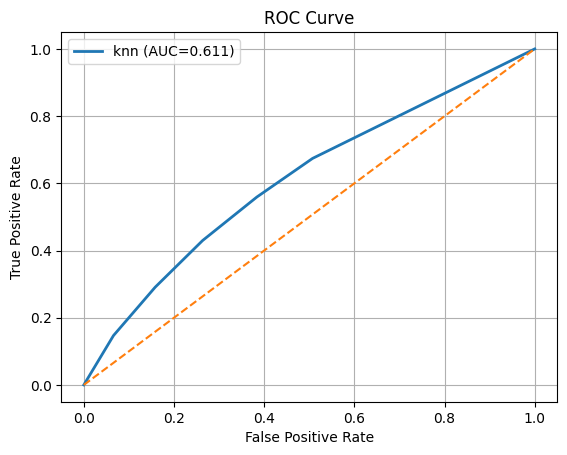

In [26]:
from src.evaluate import (
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall,
    plot_feature_importance
)

from src.evaluate import evaluate_model

results = evaluate_model(model, X_test, y_test)


plot_confusion_matrix(
    results["confusion_matrix"],
    class_names=["No Default", "Default"]
)

roc = results["roc_curve"]
plot_roc_curve(roc["fpr"], roc["tpr"], label=f'{model_name}')




In [ ]:
joblib.dump(artifacts, ARTIFACTS_PATH /"preprocess_artifacts.joblib")

['D:/projects/CreditPathAI_Oct_Batch/kaggle_dataset/artifacts/preprocess_artifacts.joblib']